In [41]:
# =============================================================================
# SCRIPT 2: ResNet50V2 Transfer Learning — Fungal Keratitis vs. Normal Cornea
# =============================================================================
# Architecture : ImageNet-pretrained ResNet50V2 (frozen) + GAP + Dense head
# Strategy     : Feature extraction only (base model fully frozen)
# Framework    : TensorFlow / Keras  |  Eval: Scikit-Learn, Matplotlib, Seaborn
# =============================================================================


# ──────────────────────────────────────────────────────────────────────────────
DATASET_PATH    = "/content/dataset"        # root: contains fungal/ and normal/
MODEL_SAVE_PATH = "/content/best_resnet50v2.keras"    # checkpoint destination
# ──────────────────────────────────────────────────────────────────────────────


In [42]:
import os
import imghdr
from pathlib import Path

VALID_FORMATS = {"jpeg", "png", "gif", "bmp", "webp"}
bad_files = []

for fpath in Path(DATASET_PATH).rglob("*"):
    if fpath.is_file():
        kind = imghdr.what(fpath)
        if kind not in VALID_FORMATS:
            bad_files.append((str(fpath), kind))

print(f"Found {len(bad_files)} bad files:")
for f, kind in bad_files:
    print(f"  {f}  →  detected as: {kind}")

Found 0 bad files:


In [43]:
import os
from pathlib import Path

# Check for duplicate images across train/val split
# Since you use random split, same patient's images may be in both sets
all_files = list(Path(DATASET_PATH).rglob("*.jpg"))  # or .png
print(f"Total images: {len(all_files)}")

# Check file sizes — duplicates often have identical sizes
sizes = [os.path.getsize(f) for f in all_files]
from collections import Counter
dupes = [s for s, c in Counter(sizes).items() if c > 1]
print(f"Potentially duplicate files (same size): {len(dupes)}")

Total images: 1396
Potentially duplicate files (same size): 51


In [44]:
import hashlib
from pathlib import Path
from collections import defaultdict

def file_hash(filepath):
    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()
hash_map = defaultdict(list)

for fpath in Path(DATASET_PATH).rglob("*"):
    if fpath.is_file() and fpath.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
        h = file_hash(fpath)
        hash_map[h].append(str(fpath))

true_duplicates = {h: paths for h, paths in hash_map.items() if len(paths) > 1}

print(f"True duplicate groups : {len(true_duplicates)}")
print(f"Total duplicate files : {sum(len(v)-1 for v in true_duplicates.values())}")
print()
for h, paths in true_duplicates.items():
    print(f"  Hash {h[:8]}...")
    for p in paths:
        print(f"    {p}")

True duplicate groups : 24
Total duplicate files : 24

  Hash 9493ac16...
    /content/dataset/fungal/13 (3).jpg
    /content/dataset/fungal/7 (35).jpg
  Hash 44dd0189...
    /content/dataset/fungal/f28.jpg
    /content/dataset/fungal/f29.jpg
  Hash 56f7e5fe...
    /content/dataset/fungal/4 (77).jpg
    /content/dataset/fungal/11 (8).jpg
  Hash 18f3bca4...
    /content/dataset/normal/73_1.jpg
    /content/dataset/normal/74_1.jpg
  Hash 6410630f...
    /content/dataset/normal/73_4.jpg
    /content/dataset/normal/74_4.jpg
  Hash 4b8b0e4b...
    /content/dataset/normal/68_3.jpg
    /content/dataset/normal/67_6.jpg
  Hash 7b28a50e...
    /content/dataset/normal/67_1.jpg
    /content/dataset/normal/66_1.jpg
  Hash a2a4a7b4...
    /content/dataset/normal/52_1.jpg
    /content/dataset/normal/51_1.jpg
  Hash 24f307c1...
    /content/dataset/normal/73_3.jpg
    /content/dataset/normal/74_3.jpg
  Hash 585f2433...
    /content/dataset/normal/68_5.jpg
    /content/dataset/normal/67_8.jpg
  Hash 32

In [45]:
# After running above, check which class has more duplicates
fungal_dupes = 0
normal_dupes = 0

for h, paths in true_duplicates.items():
    for p in paths[1:]:   # [1:] = the redundant copies
        if "fungal" in p.lower():
            fungal_dupes += 1
        elif "normal" in p.lower():
            normal_dupes += 1

print(f"Duplicate fungal images : {fungal_dupes}")
print(f"Duplicate normal images : {normal_dupes}")

Duplicate fungal images : 3
Duplicate normal images : 21


In [46]:
# Look at your filenames — do they follow a pattern like:
# patient001_image1.jpg, patient001_image2.jpg ?

all_files = list(Path(DATASET_PATH).rglob("*.jpg"))
print("Sample filenames:")
for f in all_files[:20]:
    print(f"  {f.name}")

Sample filenames:
  5 (83).jpg
  5 (89).jpg
  7 (27).jpg
  f14.jpg
  3 (98).jpg
  2 (95).jpg
  4 (94).jpg
  4 (61).jpg
  1 (30).jpg
  1 (58).jpg
  6 (16).jpg
  1 OS.jpg
  2 (49).jpg
  3 (57).jpg
  2 (92).jpg
  2 (105).jpg
  5 (28).jpg
  9 (5).jpg
  1 (9).jpg
  8 (20).jpg


In [47]:
removed = 0
for h, paths in true_duplicates.items():
    for duplicate in paths[1:]:   # keep paths[0], remove the rest
        print(f"Removing: {duplicate}")
        os.remove(duplicate)
        removed += 1

print(f"\nRemoved {removed} duplicate files. Retrain from scratch.")

Removing: /content/dataset/fungal/7 (35).jpg
Removing: /content/dataset/fungal/f29.jpg
Removing: /content/dataset/fungal/11 (8).jpg
Removing: /content/dataset/normal/74_1.jpg
Removing: /content/dataset/normal/74_4.jpg
Removing: /content/dataset/normal/67_6.jpg
Removing: /content/dataset/normal/66_1.jpg
Removing: /content/dataset/normal/51_1.jpg
Removing: /content/dataset/normal/74_3.jpg
Removing: /content/dataset/normal/67_8.jpg
Removing: /content/dataset/normal/67_0.jpg
Removing: /content/dataset/normal/68_2.jpg
Removing: /content/dataset/normal/73_5.jpg
Removing: /content/dataset/normal/67_7.jpg
Removing: /content/dataset/normal/52_0.jpg
Removing: /content/dataset/normal/74_0.jpg
Removing: /content/dataset/normal/52_5.jpg
Removing: /content/dataset/normal/68_0.jpg
Removing: /content/dataset/normal/73_2.jpg
Removing: /content/dataset/normal/68_1.jpg
Removing: /content/dataset/normal/51_2.jpg
Removing: /content/dataset/normal/51_4.jpg
Removing: /content/dataset/normal/51_3.jpg
Removing

In [48]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── Hyper-parameters ──────────────────────────────────────────────────────────
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 10
# Lower LR is crucial for transfer learning — we don't want to destroy the
# ImageNet feature representations learned by the frozen base.
LR         = 1e-4
VAL_SPLIT  = 0.20


In [49]:


# =============================================================================
# 1.  DATA LOADING
# =============================================================================

print("\n[1/6]  Loading datasets …")

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
)

CLASS_NAMES = train_ds.class_names
print(f"   Classes : {CLASS_NAMES}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)


[1/6]  Loading datasets …
Found 1372 files belonging to 2 classes.
Using 1098 files for training.
Found 1372 files belonging to 2 classes.
Using 274 files for validation.
   Classes : ['fungal', 'normal']


In [50]:
# =============================================================================
# 2.  CLASS-IMBALANCE HANDLING
# =============================================================================

print("\n[2/6]  Computing class weights …")

n_classes     = len(CLASS_NAMES)
counts        = [len(os.listdir(os.path.join(DATASET_PATH, c))) for c in CLASS_NAMES]
total_samples = sum(counts)
class_weights = {i: total_samples / (n_classes * counts[i]) for i in range(n_classes)}
print(f"   Sample counts : { {CLASS_NAMES[i]: counts[i] for i in range(n_classes)} }")
print(f"   Class weights : { {CLASS_NAMES[i]: round(class_weights[i], 4) for i in range(n_classes)} }")


[2/6]  Computing class weights …
   Sample counts : {'fungal': 860, 'normal': 512}
   Class weights : {'fungal': 0.7977, 'normal': 1.3398}


In [51]:


# =============================================================================
# 3.  DATA AUGMENTATION
# =============================================================================

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    tf.keras.layers.RandomRotation(0.20, seed=SEED),
    tf.keras.layers.RandomZoom(0.20, seed=SEED),
    tf.keras.layers.RandomContrast(0.15, seed=SEED),   # ADD THIS
    tf.keras.layers.RandomBrightness(0.15, seed=SEED), # ADD THIS
    tf.keras.layers.GaussianNoise(0.05, seed=SEED),    # ADD THIS
], name="augmentation")


In [52]:
# =============================================================================
# 4.  MODEL DEFINITION  —  ResNet50V2 Feature Extractor
# =============================================================================
# ResNet50V2 improves on ResNet50 by moving BatchNorm + ReLU *before* each
# convolution (pre-activation residuals), giving better gradient flow.
# We load it WITHOUT its top classification layer (include_top=False) and
# freeze every weight so only our new head is trained.

print("\n[3/6]  Building ResNet50V2 model …")

# ── Inputs & augmentation ─────────────────────────────────────────────────────
inputs = tf.keras.Input(shape=(*IMG_SIZE, 3), name="input_image")
x      = augmentation(inputs)

# ── ResNet50V2 preprocessing ──────────────────────────────────────────────────
# This scales pixels to [-1, 1], matching the distribution the network was
# trained on.  Always use the matching preprocess_input function!
x = tf.keras.applications.resnet_v2.preprocess_input(x)

# ── Frozen base ───────────────────────────────────────────────────────────────
base_model = tf.keras.applications.ResNet50V2(
    include_top=False,            # drop original ImageNet head
    weights="imagenet",           # load pretrained weights
    input_shape=(*IMG_SIZE, 3),
)
base_model.trainable = False      # freeze ALL layers — feature extraction mode

print(f"   ResNet50V2 total layers      : {len(base_model.layers)}")
print(f"   Trainable layers (head only) : frozen base → 0 base params trained")

x       = base_model(x, training=False)  # training=False → BN uses stored stats

# ── Classification head ───────────────────────────────────────────────────────
# GlobalAveragePooling collapses the spatial grid (7×7) into a single vector,
# drastically reducing parameters vs. Flatten.
# Replace your current head with this:
x       = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
x       = tf.keras.layers.BatchNormalization()(x)
x       = tf.keras.layers.Dropout(0.5)(x)              # was 0.3 → raise to 0.5
x       = tf.keras.layers.Dense(
              128,                                       # was 256 → reduce to 128
              activation="relu",
              kernel_regularizer=tf.keras.regularizers.l2(1e-3)  # ADD L2
          )(x)
x       = tf.keras.layers.Dropout(0.5)(x)              # was 0.3 → raise to 0.5
outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="prediction")(x)

model = tf.keras.Model(inputs, outputs, name="ResNet50V2_FeatureExtractor")
model.summary()


[3/6]  Building ResNet50V2 model …
   ResNet50V2 total layers      : 190
   Trainable layers (head only) : frozen base → 0 base params trained


Model: "ResNet50V2_FeatureExtractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,835,393 (90.92 MB)

 Trainable params: 266,497 (1.02 MB)

 Non-trainable params: 23,568,896 (89.91 MB)

In [53]:
# =============================================================================
# 5.  COMPILATION & CALLBACKS
# =============================================================================

print("\n[4/6]  Compiling model …")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-8,
        verbose=1,
    ),
]


[4/6]  Compiling model …


In [54]:

# =============================================================================
# 6.  TRAINING  (head-only phase)
# =============================================================================

print("\n[5/6]  Training (head only — base frozen) …")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)


[5/6]  Training (head only — base frozen) …
Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.6471 - auc: 0.6797 - loss: 1.0713 - precision: 0.5465 - recall: 0.5130
Epoch 1: val_loss improved from None to 0.56973, saving model to /content/best_resnet50v2.keras

Epoch 1: finished saving model to /content/best_resnet50v2.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 291ms/step - accuracy: 0.7486 - auc: 0.8193 - loss: 0.8067 - precision: 0.6437 - recall: 0.6983 - val_accuracy: 0.9672 - val_auc: 0.9859 - val_loss: 0.5697 - val_precision: 0.9722 - val_recall: 0.9459 - learning_rate: 1.0000e-04
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8833 - auc: 0.9489 - loss: 0.5262 - precision: 0.7817 - recall: 0.9276
Epoch 2: val_loss improved from 0.56973 to 0.47915, saving model to /content/best_resnet50v2.keras

Epoch 2: finished saving model to /content/best_resnet50v2.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - accuracy: 0.8916 - auc: 0.9665 - loss: 0.4774 - pre

In [56]:


# =============================================================================
# 7.  OPTIONAL FINE-TUNING PHASE
# =============================================================================
# After the head has converged, we can unfreeze the top ~30 layers of the base
# and continue training at an even lower LR to squeeze out extra performance.
# Comment this block out if you only want feature-extraction mode.

print("\n   ── Fine-tuning top 30 layers of ResNet50V2 ──")
base_model.trainable = True
for layer in base_model.layers[:-30]:    # keep the first N-30 layers frozen
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR / 10),  # 1e-5
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc"),
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall")],
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,                   # short fine-tune pass
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

# Merge both history dicts for smooth plotting
for key in history.history:
    if key in history_ft.history:
        history.history[key].extend(history_ft.history[key])


   ── Fine-tuning top 30 layers of ResNet50V2 ──
Epoch 1/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9584 - auc: 0.9940 - loss: 0.3099 - precision: 0.9413 - recall: 0.9512
Epoch 1: val_loss improved from 0.32127 to 0.28952, saving model to /content/best_resnet50v2.keras

Epoch 1: finished saving model to /content/best_resnet50v2.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 24s 317ms/step - accuracy: 0.9481 - auc: 0.9918 - loss: 0.3234 - precision: 0.9038 - recall: 0.9601 - val_accuracy: 0.9818 - val_auc: 0.9969 - val_loss: 0.2895 - val_precision: 0.9649 - val_recall: 0.9910 - learning_rate: 1.0000e-05
Epoch 2/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9605 - auc: 0.9960 - loss: 0.2954 - precision: 0.9194 - recall: 0.9746
Epoch 2: val_loss improved from 0.28952 to 0.28472, saving model to /content/best_resnet50v2.keras

Epoch 2: finished saving model to /content/best_resnet50v2.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 253ms/step - accuracy: 0.9636 - auc: 0.9954 - loss: 0.29


[6/6]  Evaluating and plotting …

── Classification Report ──────────────────────────────────────
              precision    recall  f1-score   support

      fungal     0.9938    0.9755    0.9845       163
      normal     0.9649    0.9910    0.9778       111

    accuracy                         0.9818       274
   macro avg     0.9793    0.9832    0.9811       274
weighted avg     0.9821    0.9818    0.9818       274



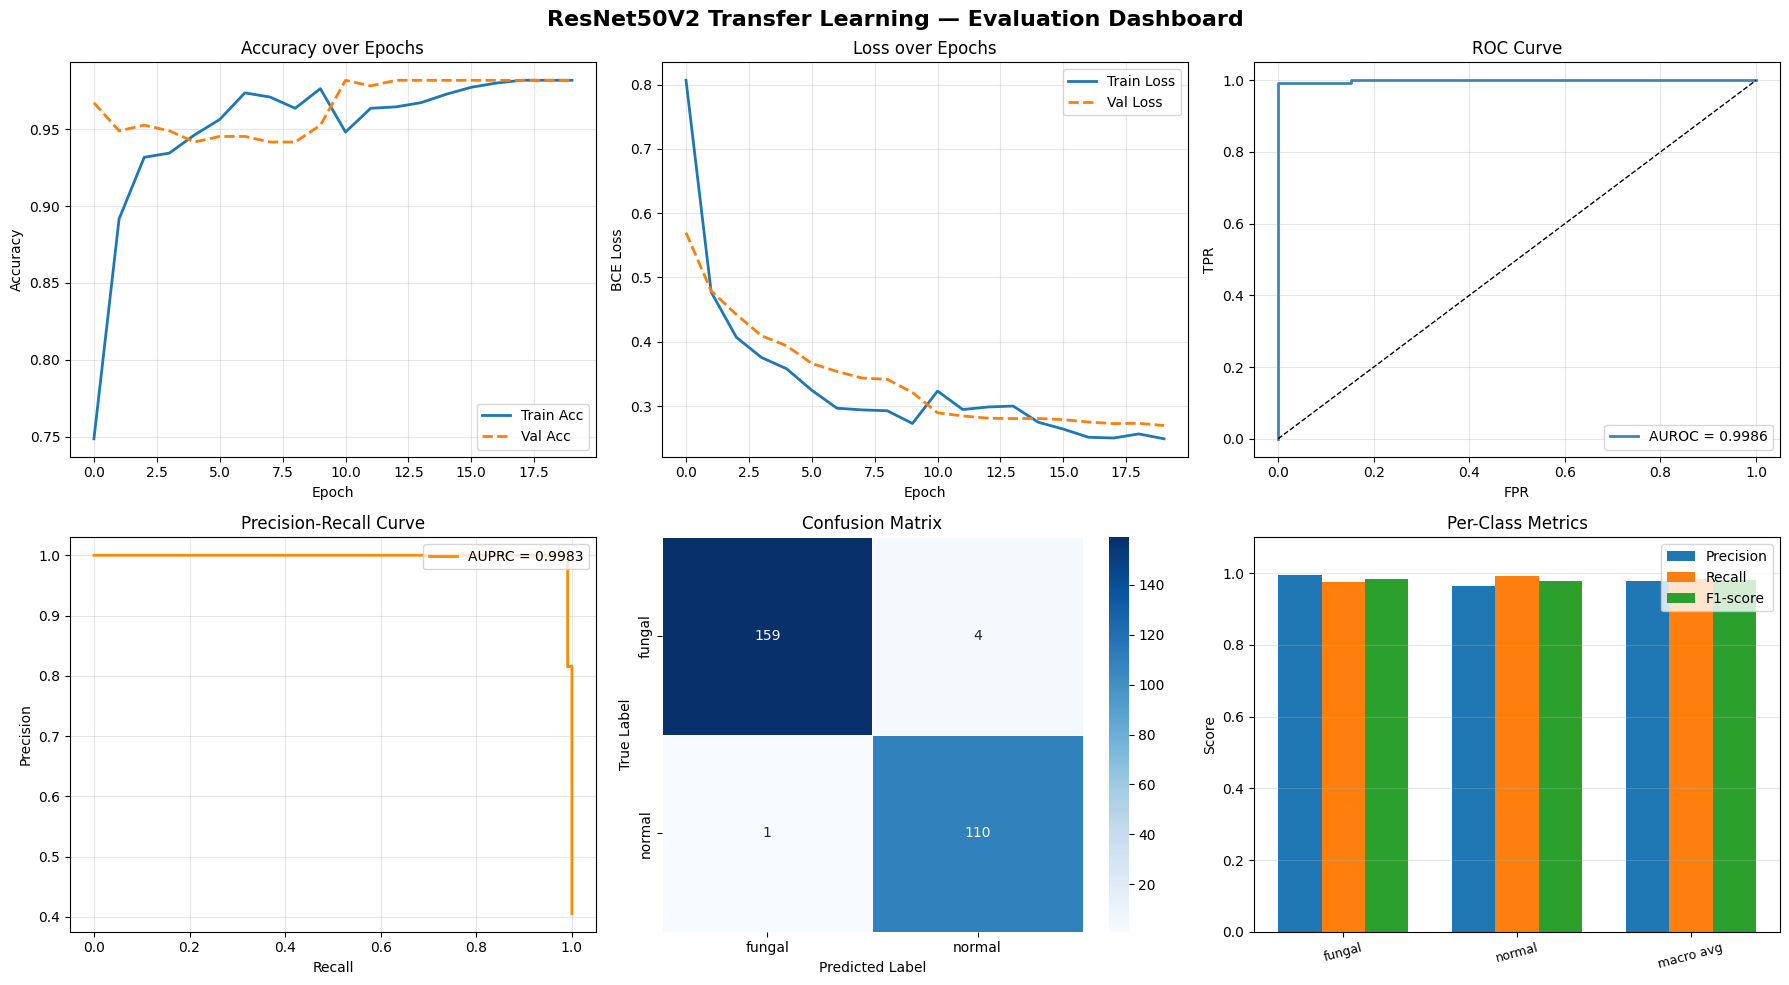


✅  Saved to  resnet50v2_evaluation.png
   AUROC : 0.9986   |   AUPRC : 0.9983


In [57]:


# =============================================================================
# 8.  EVALUATION & VISUALISATION
# =============================================================================

print("\n[6/6]  Evaluating and plotting …")

y_true, y_prob = [], []
for images, labels in val_ds:
    probs = model(images, training=False).numpy().flatten()
    y_prob.extend(probs)
    y_true.extend(labels.numpy().flatten())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

print("\n── Classification Report ──────────────────────────────────────")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("ResNet50V2 Transfer Learning — Evaluation Dashboard",
             fontsize=16, fontweight="bold")

# Panel 1 — Accuracy
ax = axes[0, 0]
ax.plot(history.history["accuracy"],     label="Train Acc",  lw=2)
ax.plot(history.history["val_accuracy"], label="Val Acc",    lw=2, ls="--")
ax.set_title("Accuracy over Epochs"); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.legend(); ax.grid(alpha=0.3)

# Panel 2 — Loss
ax = axes[0, 1]
ax.plot(history.history["loss"],     label="Train Loss", lw=2)
ax.plot(history.history["val_loss"], label="Val Loss",   lw=2, ls="--")
ax.set_title("Loss over Epochs"); ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
ax.legend(); ax.grid(alpha=0.3)

# Panel 3 — ROC
ax = axes[0, 2]
fpr, tpr, _ = roc_curve(y_true, y_prob)
auroc = auc(fpr, tpr)
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUROC = {auroc:.4f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC Curve"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)

# Panel 4 — PR Curve
ax = axes[1, 0]
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
auprc = average_precision_score(y_true, y_prob)
ax.plot(recall_vals, precision_vals, color="darkorange", lw=2, label=f"AUPRC = {auprc:.4f}")
ax.set_title("Precision-Recall Curve"); ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(loc="upper right"); ax.grid(alpha=0.3)

# Panel 5 — Confusion Matrix
ax = axes[1, 1]
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")

# Panel 6 — Per-Class Bar Chart
ax = axes[1, 2]
report  = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
grp     = CLASS_NAMES + ["macro avg"]
metrics = ["precision", "recall", "f1-score"]
data    = np.array([[report[c][m] for m in metrics] for c in grp])
x       = np.arange(len(grp)); w = 0.25
for i, m in enumerate(metrics):
    ax.bar(x + i * w, data[:, i], w, label=m.capitalize())
ax.set_xticks(x + w); ax.set_xticklabels(grp, rotation=15, fontsize=9)
ax.set_ylim(0, 1.1); ax.set_ylabel("Score"); ax.set_title("Per-Class Metrics")
ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("resnet50v2_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅  Saved to  resnet50v2_evaluation.png")
print(f"   AUROC : {auroc:.4f}   |   AUPRC : {auprc:.4f}")